<a href="https://colab.research.google.com/github/anp2/Declarative-Pipeline/blob/master/EcommProj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

from google.colab import files
uploaded = files.upload()

Saving CustomersData.csv to CustomersData.csv
Saving Discount_Coupon.csv to Discount_Coupon.csv
Saving Marketing_Spend.csv to Marketing_Spend.csv
Saving Online_Sales.csv to Online_Sales.csv
Saving Tax_amount.xlsx to Tax_amount.xlsx


In [2]:
customer_df = pd.read_csv('CustomersData.csv')
disc_coupon_df = pd.read_csv('Discount_Coupon.csv')
sales_df = pd.read_csv('Online_Sales.csv')
marketing_df = pd.read_csv('Marketing_Spend.csv')
tax_df = pd.read_excel('Tax_amount.xlsx')
sales_df['CustomerID'] = sales_df['CustomerID'].astype(str)
sales_df['Transaction_ID'] = sales_df['Transaction_ID'].astype(str)
sales_df['Product_SKU'] = sales_df['Product_SKU'].astype(str)
customer_df['CustomerID'] = customer_df['CustomerID'].astype(str)
sales_df['Transaction_Date'] = pd.to_datetime(
    sales_df['Transaction_Date']
)
marketing_df['Date'] = pd.to_datetime(
    marketing_df['Date']
)
sales_df['Month'] = sales_df['Transaction_Date'].dt.month_name()
marketing_df['Month'] = marketing_df['Date'].dt.month_name()

In [3]:
merged_df = sales_df.merge(
    customer_df,
    on='CustomerID',
    how='left'
)
merged_df = merged_df.merge(
    tax_df,
    on='Product_Category',
    how='left'
)
merged_df = merged_df.merge(
    disc_coupon_df,
    on=['Month', 'Product_Category'],
    how='left'
)
merged_df = merged_df.merge(
    marketing_df,
    left_on='Transaction_Date',
    right_on='Date',
    how='left'
)
merged_df.drop(
    columns='Date',
    inplace=True
)
merged_df['GST'] = (
    merged_df['GST']
    .fillna(0)
)
merged_df['Discount_pct'] = (
    merged_df['Discount_pct']
    .fillna(0)
)
merged_df['Offline_Spend'] = (
    merged_df['Offline_Spend']
    .fillna(0)
)
merged_df['Online_Spend'] = (
    merged_df['Online_Spend']
    .fillna(0)
)
required_columns = [
    'Quantity',
    'Avg_Price',
    'Discount_pct',
    'GST',
    'Delivery_Charges'
]

In [4]:
numeric_cols = [
    'Quantity',
    'Avg_Price',
    'Discount_pct',
    'GST',
    'Delivery_Charges'
]
for col in numeric_cols:
    merged_df[col] = pd.to_numeric(
        merged_df[col],
        errors='coerce'
    )
merged_df[numeric_cols] = (
    merged_df[numeric_cols]
    .fillna(0)
)
if merged_df['Discount_pct'].max() > 1:
    merged_df['Discount_pct'] = (
        merged_df['Discount_pct'] / 100
    )
if merged_df['GST'].max() > 1:
    merged_df['GST'] = (
        merged_df['GST'] / 100
    )

In [5]:
merged_df['Base_Amount'] = (
    merged_df['Quantity']
    * merged_df['Avg_Price']
)
merged_df['Discounted_Amount'] = (
    merged_df['Base_Amount']
    * (1 - merged_df['Discount_pct'])
)
merged_df['Taxed_Amount'] = (
    merged_df['Discounted_Amount']
    * (1 + merged_df['GST'])
)
merged_df['Taxed_Amount'] = (
    merged_df['Discounted_Amount']
    * (1 + merged_df['GST'])
)
merged_df['Invoice_Value'] = (
    merged_df['Taxed_Amount']
    + merged_df['Delivery_Charges']
)
total_revenue = (
    merged_df['Invoice_Value']
    .sum()
)
print(
    f'Total Revenue: ₹{total_revenue:,.2f}'
)
total_orders = (
    merged_df['Transaction_ID']
    .nunique()
)
print(
    f'Total Orders: {total_orders}'
)
total_customers = (
    merged_df['CustomerID']
    .nunique()
)
print(
    f'Total Customers: {total_customers}'
)
aov = (
    total_revenue
    / total_orders
)
print(
    f'Average Order Value: ₹{aov:,.2f}'
)

Total Revenue: ₹5,673,745.82
Total Orders: 25061
Total Customers: 1468
Average Order Value: ₹226.40


In [6]:
# Find each customer's first purchase date
customer_acquisition = (
    sales_df
    .groupby('CustomerID')['Transaction_Date']
    .min()
    .reset_index()
)

customer_acquisition.rename(
    columns={
        'Transaction_Date':'First_Purchase_Date'
    },
    inplace=True
)
# Extract Month
customer_acquisition['Acquisition_Month'] = (
    customer_acquisition['First_Purchase_Date']
    .dt.month_name()
)
# Count Customer Acquisitions by Month
monthly_acquisition = (
    customer_acquisition
    .groupby('Acquisition_Month')
    .size()
    .reset_index(name='Customer_Count')
)

In [7]:
# Sort Months Chronologically
month_order = [
    'January',
    'February',
    'March',
    'April',
    'May',
    'June',
    'July',
    'August',
    'September',
    'October',
    'November',
    'December'
]
monthly_acquisition['Acquisition_Month'] = pd.Categorical(
    monthly_acquisition['Acquisition_Month'],
    categories=month_order,
    ordered=True
)
monthly_acquisition = (
    monthly_acquisition
    .sort_values('Acquisition_Month')
)

In [8]:
# Identify Highest and Lowest Acquisition Months
highest_month = monthly_acquisition.loc[
    monthly_acquisition['Customer_Count'].idxmax()
]
lowest_month = monthly_acquisition.loc[
    monthly_acquisition['Customer_Count'].idxmin()
]
print(
    f"Highest Acquisition Month: "
    f"{highest_month['Acquisition_Month']} "
    f"({highest_month['Customer_Count']} customers)"
)
print(
    f"Lowest Acquisition Month: "
    f"{lowest_month['Acquisition_Month']} "
    f"({lowest_month['Customer_Count']} customers)"
)

Highest Acquisition Month: January (215 customers)
Lowest Acquisition Month: November (68 customers)


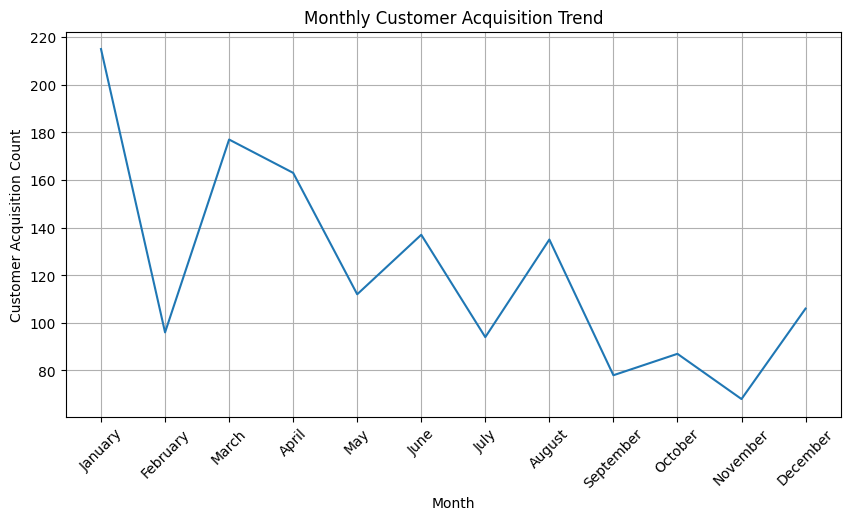

In [9]:
# Visualize the Trend
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(
    monthly_acquisition['Acquisition_Month'],
    monthly_acquisition['Customer_Count']
)
plt.xticks(rotation=45)
plt.xlabel('Month')
plt.ylabel('Customer Acquisition Count')
plt.title('Monthly Customer Acquisition Trend')
plt.grid(True)
plt.show()

In [10]:
# Analysis revealed that customer acquisition varies across months, indicating seasonality in customer behavior.
# High-performing months should be leveraged by increasing marketing investments, launching new products, and implementing customer retention programs.
# During slower months, targeted interventions such as promotional campaigns, referral programs, and personalized customer outreach
# can help stimulate demand and maintain consistent customer acquisition throughout the year.

In [11]:
# 2 - Customer behavior during high-retention months

sales_df['Year_Month'] = (
    sales_df['Transaction_Date']
    .dt.to_period('M')
)
monthly_customers = (
    sales_df
    .groupby('Year_Month')['CustomerID']
    .apply(set)
    .sort_index()
)
retention_data = []
months = monthly_customers.index.tolist()
for i in range(len(months)-1):
    current_month = months[i]
    next_month = months[i+1]
    current_customers = monthly_customers[current_month]
    next_customers = monthly_customers[next_month]
    retained_customers = (
        current_customers
        .intersection(next_customers)
    )
    retention_rate = (
        len(retained_customers)
        / len(current_customers)
    ) * 100
    retention_data.append({
        'Month': str(current_month),
        'Next_Month': str(next_month),
        'Customers_Current_Month': len(current_customers),
        'Retained_Customers': len(retained_customers),
        'Retention_Rate': round(
            retention_rate,
            2
        )
    })

In [12]:
# Create Retention DataFrame
retention_df = pd.DataFrame(
    retention_data
)
# Identify Strongest and Weakest Months
strongest = retention_df.loc[
    retention_df['Retention_Rate']
    .idxmax()
]
print(
    f"Strongest Retention: "
    f"{strongest['Month']} "
    f"({strongest['Retention_Rate']}%)"
)

Strongest Retention: 2019-07 (27.54%)


In [13]:
# customer behavior during high-retention monthsIdentify High-Retention Months

top_retention_months = (
    retention_df
    .sort_values(
        by='Retention_Rate',
        ascending=False
    )
    .head(3)
)
top_retention_months

,Month,Next_Month,Customers_Current_Month,Retained_Customers,Retention_Rate
6,2019-07,2019-08,236,65,27.54
5,2019-06,2019-07,259,58,22.39
4,2019-05,2019-06,200,37,18.50


In [14]:
# Extract those months.
high_retention_months = (
    top_retention_months['Month']
    .tolist()
)
high_retention_months

['2019-07', '2019-06', '2019-05']

In [15]:
# Filter Transactions Create Year_Month.
merged_df['Year_Month'] = (
    merged_df['Transaction_Date']
    .dt.to_period('M')
    .astype(str)
)
high_retention_sales = merged_df[
    merged_df['Year_Month']
    .isin(high_retention_months)
]

In [16]:
# Analyze Product Categories
category_analysis = (
    high_retention_sales
    .groupby('Product_Category')
    ['Quantity']
    .sum()
    .sort_values(
        ascending=False
    )
)
category_analysis

,Quantity
Product_Category,
Office,22728
Apparel,9687
Drinkware,8164
Lifestyle,7171
Nest-USA,4882
Bags,3858
Notebooks & Journals,3194
Housewares,1222
Bottles,775


In [17]:
# Analyze Coupon Usage

coupon_analysis = (
    high_retention_sales
    ['Coupon_Status']
    .value_counts()
)
coupon_analysis

,count
Coupon_Status,
Clicked,7187
Used,4668
Not Used,2161


In [18]:
# Analyze Invoice Value If Invoice_Value already exists:
invoice_analysis = (
    high_retention_sales['Invoice_Value'].describe()
)
invoice_analysis

,Invoice_Value
count,14016.000000
mean,84.250018
std,142.725648
min,6.695200
25%,18.828960
50%,31.950400
75%,117.710000
max,4727.850000


In [19]:
# Analyze Purchase Frequency
purchase_frequency = (
    high_retention_sales
    .groupby('CustomerID')
    ['Transaction_ID']
    .nunique()
)
purchase_frequency.describe()

,Transaction_ID
count,573.000000
mean,11.373473
std,12.759069
min,1.000000
25%,3.000000
50%,7.000000
75%,15.000000
max,93.000000


In [20]:
# Analyze Top Products

top_products = (
    high_retention_sales
    .groupby('Product_Description')
    ['Quantity']
    .sum()
    .sort_values(
        ascending=False
    )
    .head(10)
)
top_products

,Quantity
Product_Description,
Google 22 oz Water Bottle,4420
Maze Pen,4044
Google Sunglasses,3643
Recycled Paper Journal Set,2406
Sport Bag,1912
Google Kick Ball,1884
Foam Can and Bottle Cooler,1456
Google Metallic Notebook Set,1303
Nest Cam Outdoor Security Camera - USA,1283


In [21]:
# Create a Summary Table

summary = {
    'Average Invoice Value':
        high_retention_sales[
            'Invoice_Value'
        ].mean(),
    'Average Quantity Purchased':
        high_retention_sales[
            'Quantity'
        ].mean(),
    'Unique Customers':
        high_retention_sales[
            'CustomerID'
        ].nunique(),
    'Total Transactions':
        high_retention_sales[
            'Transaction_ID'
        ].nunique()
}
summary

{'Average Invoice Value': np.float64(84.25001807648401),
 'Average Quantity Purchased': np.float64(4.511415525114155),
 'Unique Customers': 573,
 'Total Transactions': 6054}

In [22]:
# Analysis - Customer behavior during high-retention months was analyzed by examining product categories, coupon usage,
# purchase frequency, and transaction values. High-retention periods often exhibit strong engagement with popular products,
# higher transaction values, and increased use of promotional offers. To replicate this success throughout the year,
# the company should promote top-performing products, expand loyalty programs, personalize recommendations, and apply
# successful marketing strategies during lower-performing months to encourage repeat purchases and improve long-term customer retention.

In [33]:
# Q3 -Compare the revenue generated by new and existing customers month-over-month.

merged_df['Transaction_Date'] = pd.to_datetime(
    merged_df['Transaction_Date']
)

merged_df['Year_Month'] = (
    merged_df['Transaction_Date']
    .dt.to_period('M')
)
# Find each customer's first purchase month
first_purchase = (
    merged_df
    .groupby('CustomerID')['Year_Month']
    .min()
    .reset_index()
)
first_purchase.rename(
    columns={'Year_Month':'First_Purchase_Month'},
    inplace=True
)
revenue_df = merged_df.merge(
    first_purchase,
    on='CustomerID',
    how='left'
)
# Classify Customers as New or Existing
revenue_df['Customer_Type'] = np.where(
    revenue_df['Year_Month'] == revenue_df['First_Purchase_Month'],
    'New',
    'Existing'
)

In [35]:
# Calculate monthly revenue by Customer Type
monthly_revenue = (
    revenue_df
    .groupby(['Year_Month','Customer_Type'])['Invoice_Value']
    .sum()
    .reset_index()
)

monthly_revenue.head()

,Year_Month,Customer_Type,Invoice_Value
0,2019-01,New,508514.7551
1,2019-02,Existing,49784.6856
2,2019-02,New,347080.9714
3,2019-03,Existing,74933.2394
4,2019-03,New,378271.8279


In [36]:
# Create a Pivot Table
revenue_pivot = (
    monthly_revenue
    .pivot(
        index='Year_Month',
        columns='Customer_Type',
        values='Invoice_Value'
    )
    .fillna(0)
)

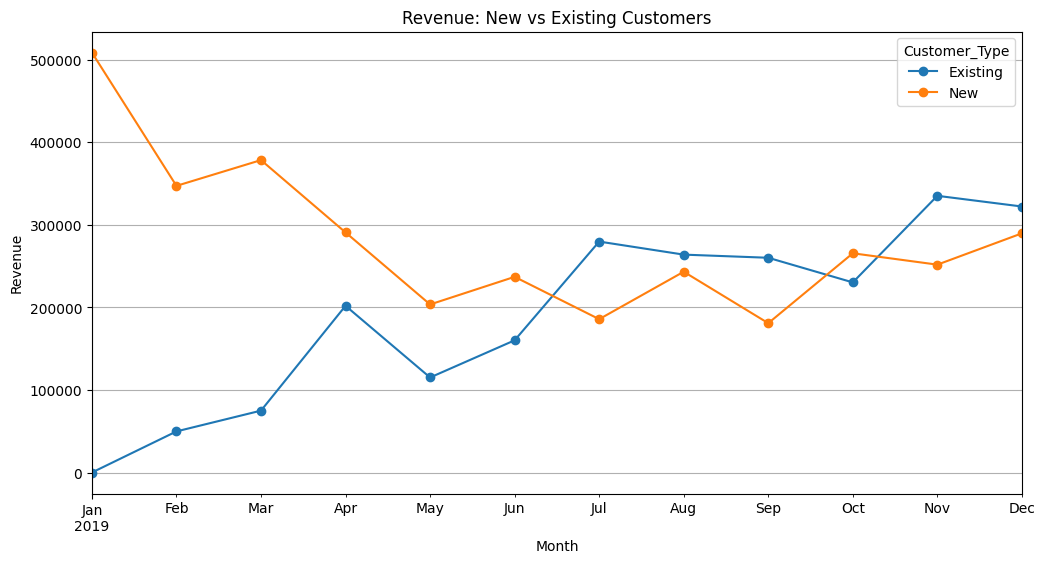

In [37]:
# Visualize the Trend

import matplotlib.pyplot as plt

revenue_pivot.plot(
    kind='line',
    figsize=(12,6),
    marker='o'
)
plt.title(
    'Revenue: New vs Existing Customers'
)
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.grid(True)
plt.show()

In [38]:
# Calculate Revenue Contribution (%)

revenue_pivot['Total_Revenue'] = (
    revenue_pivot['New']
    + revenue_pivot['Existing']
)
revenue_pivot['New_%'] = (
    revenue_pivot['New']
    / revenue_pivot['Total_Revenue']
) * 100
revenue_pivot['Existing_%'] = (
    revenue_pivot['Existing']
    / revenue_pivot['Total_Revenue']
) * 100
revenue_pivot.round(2)

Customer_Type,Existing,New,Total_Revenue,New_%,Existing_%
Year_Month,,,,,
2019-01,0.00,508514.76,508514.76,100.00,0.00
2019-02,49784.69,347080.97,396865.66,87.46,12.54
2019-03,74933.24,378271.83,453205.07,83.47,16.53
2019-04,201853.32,290706.38,492559.71,59.02,40.98
2019-05,115067.71,203488.59,318556.30,63.88,36.12
2019-06,160076.15,236926.78,397002.93,59.68,40.32
2019-07,279620.57,185668.45,465289.02,39.90,60.10
2019-08,263821.96,243114.65,506936.61,47.96,52.04
2019-09,260016.98,180805.44,440822.43,41.02,58.98


In [39]:
# Analysis - Customers were classified as new or existing based on their first purchase month. Monthly revenue was then
# calculated separately for each group using Invoice_Value. Comparing these trends helps determine whether business growth
# is driven primarily by customer acquisition or by retaining existing customers. A balanced contribution from both groups
# indicates sustainable growth, while over-reliance on either group suggests opportunities to strengthen acquisition or retention strategies.

In [49]:
# 4 - Identify the top-performing products and analyze the factors driving their success.
# Top Products by Revenue

top_products_revenue = (
    merged_df
    .groupby('Product_Category')
    .agg(
        Total_Revenue=('Invoice_Value','sum'),
        Quantity_Sold=('Quantity','sum'),
        Total_Orders=('Transaction_ID','nunique')
    )
    .reset_index()
    .sort_values(
        'Total_Revenue',
        ascending=False
    )
)
top_products_revenue.head(10)
# Top Products by Quantity Sold
top_products_quantity = (
    merged_df
    .groupby('Product_Category')
    .agg(
        Quantity_Sold=('Quantity','sum'),
        Total_Revenue=('Invoice_Value','sum')
    )
    .reset_index()
    .sort_values(
        'Quantity_Sold',
        ascending=False
    )
)
top_products_quantity.head(10)
# Analyze Discounts
product_discount_analysis = (
    merged_df
    .groupby('Product_Category')
    .agg(
        Avg_Discount=('Discount_pct','mean'),
        Revenue=('Invoice_Value','sum')
    )
    .reset_index()
    .sort_values(
        'Revenue',
        ascending=False
    )
)
product_discount_analysis.head(10)
# Analyze Categories
category_analysis = (
    merged_df
    .groupby('Product_Category')
    .agg(
        Revenue=('Invoice_Value','sum'),
        Quantity=('Quantity','sum')
    )
    .reset_index()
    .sort_values(
        'Revenue',
        ascending=False
    )
)
category_analysis

,Product_Category,Revenue,Quantity
16,Nest-USA,2.871085e+06,21430
2,Apparel,8.605277e+05,32438
14,Nest,5.601860e+05,2837
18,Office,3.978568e+05,88383
6,Drinkware,2.830873e+05,30501
4,Bags,2.018448e+05,15273
12,Lifestyle,1.296539e+05,24881
17,Notebooks & Journals,1.270014e+05,9556
15,Nest-Canada,8.007147e+04,469
10,Headgear,6.297333e+04,3533


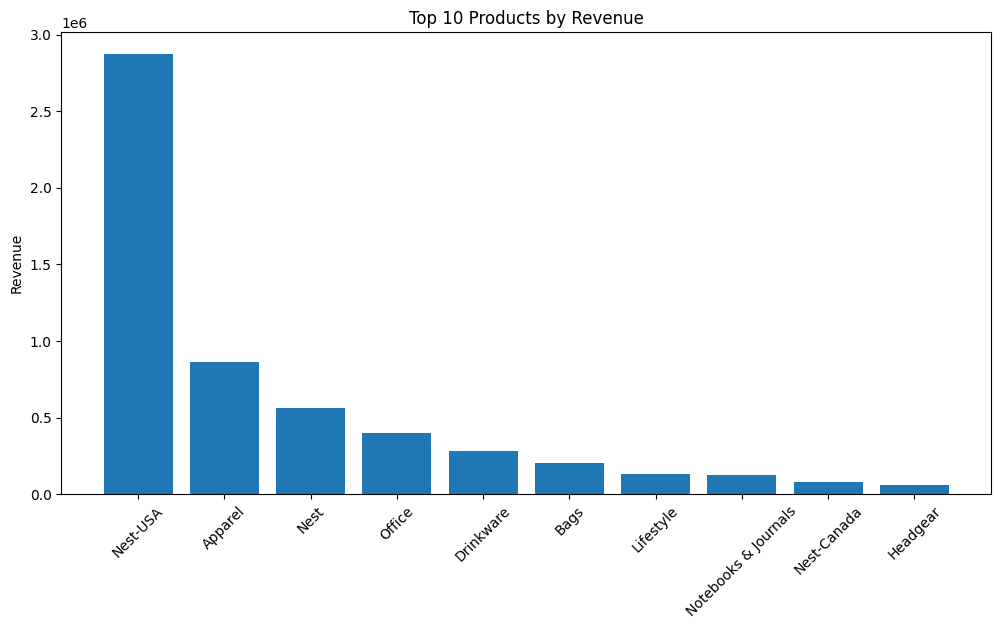

In [52]:
# Visualize Top Products by Revenue
import matplotlib.pyplot as plt
top10 = top_products_revenue.head(10)
plt.figure(figsize=(12,6))
plt.bar(
    top10['Product_Category'],
    top10['Total_Revenue']
)
plt.xticks(rotation=45)
plt.title(
    'Top 10 Products by Revenue'
)
plt.ylabel('Revenue')
plt.show()

In [53]:
# Q4 Analysis - Top-performing products were identified based on both total quantity sold and total revenue generated.
# Their product categories, pricing, and coupon usage patterns were analyzed to understand the factors contributing to
# their success. These insights can guide inventory planning by maintaining adequate stock levels for high-demand products
# and improve promotional strategies through cross-selling, bundling, personalized recommendations, and targeted marketing campaigns.
# Effective inventory management reduces stockout risks while maximizing revenue opportunities.

In [54]:
# Q5 - Segment customers into groups such as Premium, Gold, Silver, and Standard.
# Create Customer-Level RFM Table
import pandas as pd
import numpy as np

# Ensure date column is datetime
merged_df['Transaction_Date'] = pd.to_datetime(
    merged_df['Transaction_Date']
)

# Reference date
snapshot_date = merged_df['Transaction_Date'].max() + pd.Timedelta(days=1)

rfm = (
    merged_df
    .groupby('CustomerID')
    .agg(
        Recency=('Transaction_Date',
                 lambda x: (snapshot_date - x.max()).days),
        Frequency=('Transaction_ID',
                   'nunique'),
        Monetary=('Invoice_Value',
                  'sum')
    )
    .reset_index()
)
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,108,1,185.6882
1,12347,60,31,16567.9470
2,12348,74,8,1842.8708
3,12350,18,11,1636.2142
4,12356,108,13,2231.7198


In [56]:
# RFM Scores
rfm['R_Score'] = pd.qcut(
    rfm['Recency'],
    4,
    labels=[4,3,2,1]
)
rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    4,
    labels=[1,2,3,4]
)
rfm['M_Score'] = pd.qcut(
    rfm['Monetary'],
    4,
    labels=[1,2,3,4]
)
# Calculate Total RFM Score
rfm['RFM_Score'] = (
    rfm['R_Score'].astype(int)
    +
    rfm['F_Score'].astype(int)
    +
    rfm['M_Score'].astype(int)
)

In [57]:
# Custom Segments
def segment_customer(score):
    if score >= 10:
        return 'Premium'
    elif score >= 8:
        return 'Gold'
    elif score >= 6:
        return 'Silver'
    else:
        return 'Standard'

rfm['Customer_Segment'] = (
    rfm['RFM_Score']
    .apply(segment_customer)
)
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Customer_Segment
0,12346,108,1,185.6882,3,1,1,5,Standard
1,12347,60,31,16567.9470,3,4,4,11,Premium
2,12348,74,8,1842.8708,3,2,2,7,Silver
3,12350,18,11,1636.2142,4,2,2,8,Gold
4,12356,108,13,2231.7198,3,3,3,9,Gold


In [58]:
# Segment Summary
segment_summary = (
    rfm
    .groupby('Customer_Segment')
    .agg(
        Customers=('CustomerID','count'),
        Avg_Recency=('Recency','mean'),
        Avg_Frequency=('Frequency','mean'),
        Avg_Monetary=('Monetary','mean')
    )
    .reset_index()
)
segment_summary.round(2)

,Customer_Segment,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
0,Gold,309,141.91,18.46,3984.54
1,Premium,410,62.91,40.10,8879.66
2,Silver,342,155.13,8.92,1650.52
3,Standard,407,222.58,3.52,583.25


In [59]:
# Segment Distribution
rfm['Customer_Segment'].value_counts()

,count
Customer_Segment,
Premium,410
Standard,407
Silver,342
Gold,309


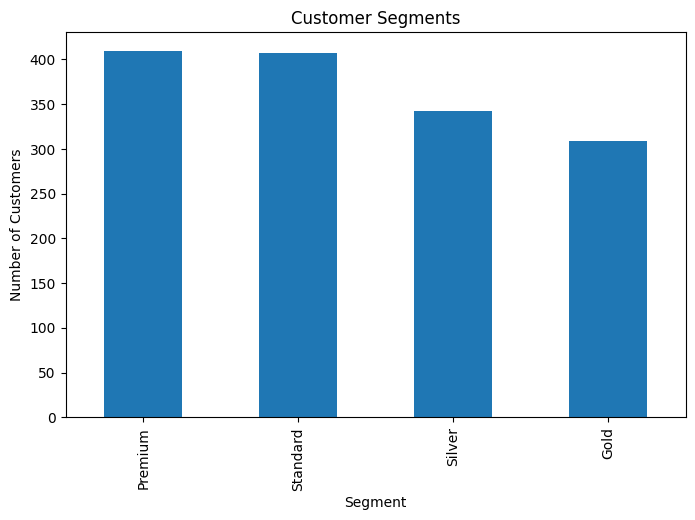

In [60]:
# Visualize
import matplotlib.pyplot as plt

segment_counts = (
    rfm['Customer_Segment']
    .value_counts()
)
plt.figure(figsize=(8,5))
segment_counts.plot(kind='bar')
plt.title('Customer Segments')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.show()

In [61]:
# Q5 - Analysis - Customers were segmented using RFM (Recency, Frequency, Monetary) analysis. Customers with the highest scores
# were classified as Premium, followed by Gold, Silver, and Standard segments. Premium customers should receive VIP experiences
# and exclusive benefits, while Gold customers should be nurtured through loyalty programs. Silver customers can be encouraged
# through cross-selling opportunities, and Standard customers can be re-engaged using targeted promotions and personalized
# campaigns. This segmentation approach helps improve retention, customer lifetime value, and overall revenue generation.

In [63]:
# Q6 - Analyze the revenue contribution of each customer segment
# Revenue Contribution by Segment
segment_revenue = (
    rfm
    .groupby('Customer_Segment')
    .agg(
        Customers=('CustomerID','count'),
        Total_Revenue=('Monetary','sum'),
        Avg_Revenue_Per_Customer=('Monetary','mean')
    )
    .reset_index()
)
segment_revenue

# Calculate Revenue Contribution %
total_revenue = segment_revenue['Total_Revenue'].sum()
segment_revenue['Revenue_Contribution_%'] = (
    segment_revenue['Total_Revenue']
    * 100
    / total_revenue
)
segment_revenue.round(2)

,Customer_Segment,Customers,Total_Revenue,Avg_Revenue_Per_Customer,Revenue_Contribution_%
0,Gold,309,1231223.77,3984.54,21.70
1,Premium,410,3640662.43,8879.66,64.17
2,Silver,342,564478.20,1650.52,9.95
3,Standard,407,237381.41,583.25,4.18


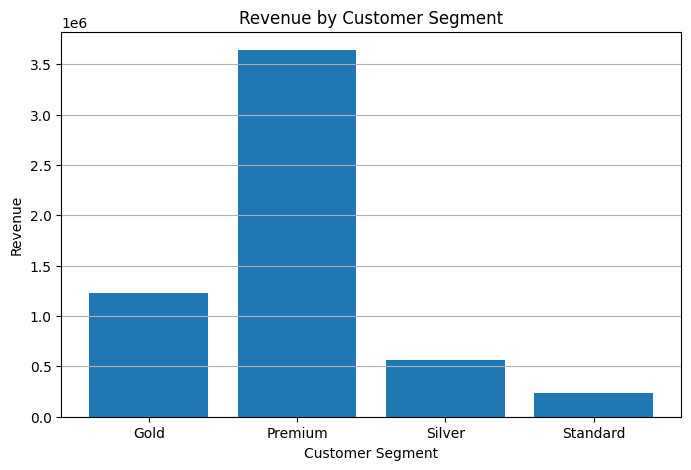

In [64]:
# Visualize Revenue Contribution - Revenue by Segment
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(
    segment_revenue['Customer_Segment'],
    segment_revenue['Total_Revenue']
)
plt.title('Revenue by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Revenue')
plt.grid(axis='y')
plt.show()

In [65]:
# Highest and Lowest Contributing Segments
highest_segment = segment_revenue.loc[
    segment_revenue['Total_Revenue'].idxmax()
]

lowest_segment = segment_revenue.loc[
    segment_revenue['Total_Revenue'].idxmin()
]

print("Highest Revenue Segment")
print(highest_segment)

print("\nLowest Revenue Segment")
print(lowest_segment)

Highest Revenue Segment
Customer_Segment                  Premium
Customers                             410
Total_Revenue               3640662.43424
Avg_Revenue_Per_Customer      8879.664474
Revenue_Contribution_%          64.166823
Name: 1, dtype: object

Lowest Revenue Segment
Customer_Segment               Standard
Customers                           407
Total_Revenue               237381.4143
Avg_Revenue_Per_Customer     583.246718
Revenue_Contribution_%         4.183857
Name: 3, dtype: object


In [67]:
# Q6 - Analysis - Revenue contribution was analyzed across customer segments created using RFM segmentation.
# Premium and Gold customers typically contribute the largest share of revenue despite representing a smaller portion of
# the customer base, indicating their high lifetime value. Silver and Standard customers contribute less revenue
# but offer growth opportunities through targeted marketing and engagement strategies. The company should prioritize
# retention and loyalty initiatives for high-value segments while implementing personalized campaigns to nurture lower-value customers and increase their contribution over time.

In [75]:
# Q7 - Group customers by their month of first purchase and analyze retention rates over time (Cohort Analysis),

merged_df['Transaction_Date'] = pd.to_datetime(
    merged_df['Transaction_Date']
)
merged_df['Transaction_Month'] = (
    merged_df['Transaction_Date']
    .dt.to_period('M')
)
cohort_df = (
    merged_df
    .groupby('CustomerID')['Transaction_Month']
    .min()
    .reset_index()
)
cohort_df.rename(
    columns={'Transaction_Month':'Cohort_Month'},
    inplace=True
)
cohort_df.head()
cohort_data = merged_df.merge(
    cohort_df,
    on='CustomerID',
    how='left'
)
cohort_data['Cohort_Index'] = (
    cohort_data['Transaction_Month']
    - cohort_data['Cohort_Month']
).apply(lambda x: x.n)
cohort_counts = (
    cohort_data
    .groupby(['Cohort_Month','Cohort_Index'])
    ['CustomerID']
    .nunique()
    .reset_index()
)
cohort_counts.head()

,Cohort_Month,Cohort_Index,CustomerID
0,2019-01,0,215
1,2019-01,1,13
2,2019-01,2,24
3,2019-01,3,34
4,2019-01,4,23


In [78]:
# Cohort Table
cohort_table = cohort_counts.pivot(
    index='Cohort_Month',
    columns='Cohort_Index',
    values='CustomerID'
)
# Calculate Retention Rates
retention_matrix = (
    cohort_table
    .divide(cohort_table[0], axis=0)
    * 100
)
retention_matrix.round(2)

# Identify Best and Worst Cohorts
month1_retention = retention_matrix[1]

best_cohort = month1_retention.idxmax()
worst_cohort = month1_retention.idxmin()

print("Best Cohort:", best_cohort)
print("Retention:", round(month1_retention.max(),2), "%")

print("\nWorst Cohort:", worst_cohort)
print("Retention:", round(month1_retention.min(),2), "%")


Best Cohort: 2019-06
Retention: 14.6 %

Worst Cohort: 2019-01
Retention: 6.05 %


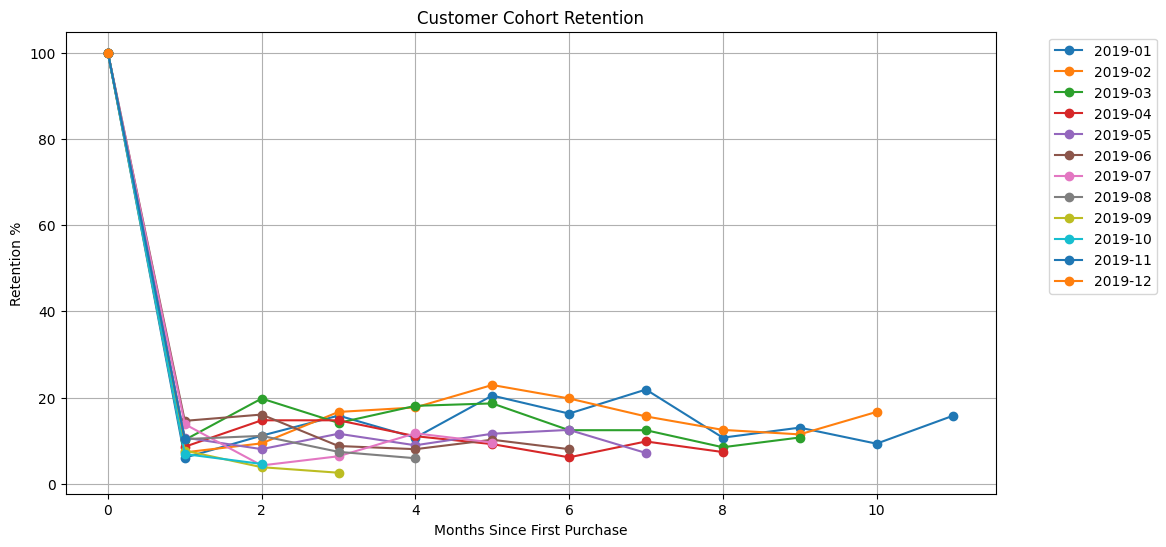

In [79]:
# Visualize Retention

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for cohort in retention_matrix.index:
    plt.plot(
        retention_matrix.columns,
        retention_matrix.loc[cohort],
        marker='o',
        label=str(cohort)
    )
plt.title('Customer Cohort Retention')
plt.xlabel('Months Since First Purchase')
plt.ylabel('Retention %')
plt.legend(
    bbox_to_anchor=(1.05,1),
    loc='upper left'
)
plt.grid(True)
plt.show()

In [80]:
# Q7 - Analysis - Customers were grouped into cohorts based on their first purchase month. Retention rates were calculated
# by tracking the percentage of customers from each cohort who returned in subsequent months. The analysis identified cohorts
# with the highest and lowest retention levels, enabling the company to evaluate the effectiveness of acquisition campaigns
# and customer engagement initiatives. High-performing cohorts can serve as benchmarks for future acquisition strategies, while weaker cohorts may benefit from targeted retention programs,
# personalized marketing, loyalty rewards, and re-engagement campaigns to improve long-term customer value.

In [81]:
# Q8 - Analyze the lifetime value of customers acquired in different months.

# Create Customer Acquisition Month
merged_df['Transaction_Date'] = pd.to_datetime(
    merged_df['Transaction_Date']
)
merged_df['Transaction_Month'] = (
    merged_df['Transaction_Date']
    .dt.to_period('M')
)
first_purchase = (
    merged_df
    .groupby('CustomerID', as_index=False)
    ['Transaction_Month']
    .min()
)
first_purchase.rename(
    columns={
        'Transaction_Month':'Acquisition_Month'
    },
    inplace=True
)
first_purchase.head()

,CustomerID,Acquisition_Month
0,12346,2019-09
1,12347,2019-03
2,12348,2019-06
3,12350,2019-12
4,12356,2019-09


In [83]:
# Calculate Customer Lifetime Revenue
customer_ltv = (
    merged_df
    .groupby('CustomerID')
    .agg(
        Lifetime_Revenue=('Invoice_Value','sum'),
        Total_Orders=('Transaction_ID','nunique')
    )
    .reset_index()
)
customer_ltv.head()
# Merge Acquisition Month
customer_ltv = customer_ltv.merge(
    first_purchase,
    on='CustomerID',
    how='left'
)
customer_ltv.head()

,CustomerID,Lifetime_Revenue,Total_Orders,Acquisition_Month
0,12346,185.6882,1,2019-09
1,12347,16567.9470,31,2019-03
2,12348,1842.8708,8,2019-06
3,12350,1636.2142,11,2019-12
4,12356,2231.7198,13,2019-09


In [84]:
# Calculate LTV by Acquisition Month

ltv_by_month = (
    customer_ltv
    .groupby('Acquisition_Month')
    .agg(
        Customers=('CustomerID','count'),
        Avg_LTV=('Lifetime_Revenue','mean'),
        Total_LTV=('Lifetime_Revenue','sum'),
        Avg_Orders=('Total_Orders','mean')
    )
    .reset_index()
)
ltv_by_month.round(2)

,Acquisition_Month,Customers,Avg_LTV,Total_LTV,Avg_Orders
0,2019-01,215,5967.25,1282958.35,26.00
1,2019-02,96,6997.77,671785.67,32.32
2,2019-03,177,4644.13,822011.68,21.24
3,2019-04,163,3336.22,543803.34,15.23
4,2019-05,112,3282.04,367588.17,19.82
5,2019-06,137,2630.14,360328.50,13.68
6,2019-07,94,3092.13,290660.47,15.24
7,2019-08,135,2378.75,321130.80,12.45
8,2019-09,78,2395.15,186821.98,11.53
9,2019-10,87,3218.04,279969.55,13.91


In [88]:
# Identify Best and Worst Acquisition Cohorts
best_cohort = ltv_by_month.loc[
    ltv_by_month['Avg_LTV'].idxmax()
]
print('Highest LTV Cohort')
print(best_cohort)
worst_cohort = ltv_by_month.loc[
    ltv_by_month['Avg_LTV'].idxmin()
]
print('Lowest LTV Cohort')
print(worst_cohort)

Highest LTV Cohort
Acquisition_Month         2019-02
Customers                      96
Avg_LTV               6997.767351
Total_LTV            671785.66572
Avg_Orders              32.322917
Name: 1, dtype: object
Lowest LTV Cohort
Acquisition_Month        2019-08
Customers                    135
Avg_LTV              2378.746658
Total_LTV            321130.7988
Avg_Orders             12.451852
Name: 7, dtype: object


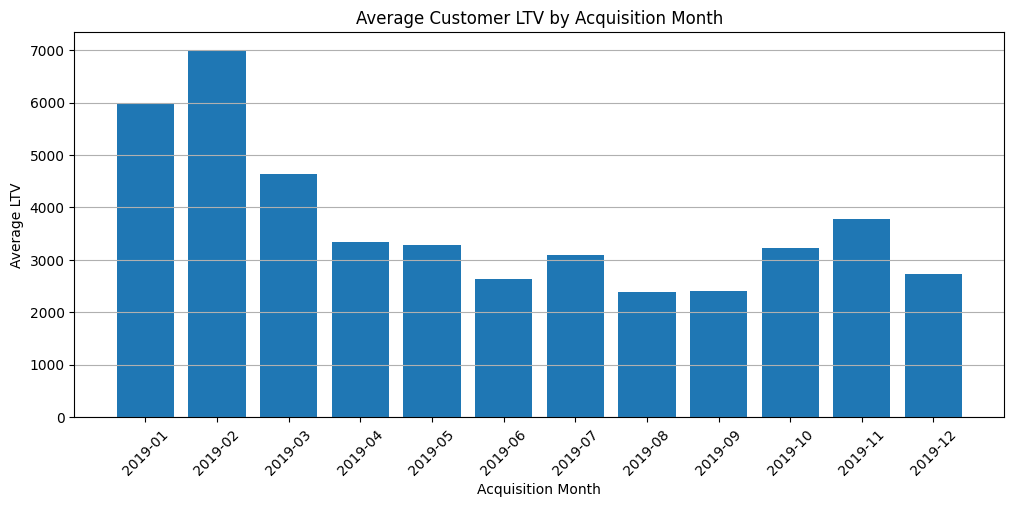

In [89]:
# Visualize LTV by Acquisition Month
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.bar(
    ltv_by_month['Acquisition_Month'].astype(str),
    ltv_by_month['Avg_LTV']
)
plt.xticks(rotation=45)
plt.title(
    'Average Customer LTV by Acquisition Month'
)
plt.xlabel('Acquisition Month')
plt.ylabel('Average LTV')
plt.grid(axis='y')
plt.show()

In [90]:
# Q8 - Analysis - Customer Lifetime Value (LTV) was analyzed by grouping customers according to their acquisition month and
# calculating the total revenue generated by each customer over their lifetime. Average LTV, total revenue contribution, and
# average order frequency were compared across acquisition cohorts. The analysis revealed which acquisition periods attracted
# the most valuable customers and which produced lower-value cohorts. These insights can help the company optimize marketing
# investments by focusing on acquisition channels and periods that generate customers with higher long-term value while
# implementing targeted retention programs to improve the value of weaker cohorts.

In [91]:
# Q9 - Identify seasonal trends in sales by category and location.

merged_df['Transaction_Date'] = pd.to_datetime(
    merged_df['Transaction_Date']
)
merged_df['Month'] = (
    merged_df['Transaction_Date']
    .dt.month_name()
)
merged_df['Month_Num'] = (
    merged_df['Transaction_Date']
    .dt.month
)

In [92]:
# Monthly Sales Trend
monthly_sales = (
    merged_df
    .groupby(['Month_Num','Month'])
    ['Invoice_Value']
    .sum()
    .reset_index()
    .sort_values('Month_Num')
)
monthly_sales

,Month_Num,Month,Invoice_Value
0,1,January,508514.75510
1,2,February,396865.65700
2,3,March,453205.06730
3,4,April,492559.70690
4,5,May,318556.30056
5,6,June,397002.93390
6,7,July,465289.01890
7,8,August,506936.61000
8,9,September,440822.42580
9,10,October,495627.71850


In [93]:
# Seasonal Trend by Product Category
category_seasonality = (
    merged_df
    .groupby(
        ['Month','Product_Category']
    )
    ['Invoice_Value']
    .sum()
    .reset_index()
)
category_seasonality.head()

,Month,Product_Category,Invoice_Value
0,April,Accessories,208.6560
1,April,Android,56.9780
2,April,Apparel,117853.2752
3,April,Backpacks,1292.9440
4,April,Bags,15183.6354


In [94]:
# Pivot Table
category_pivot = (
    category_seasonality
    .pivot(
        index='Month',
        columns='Product_Category',
        values='Invoice_Value'
    )
    .fillna(0)
)
category_pivot

Product_Category,Accessories,Android,Apparel,Backpacks,Bags,Bottles,Drinkware,Fun,Gift Cards,Google,Headgear,Housewares,Lifestyle,More Bags,Nest,Nest-Canada,Nest-USA,Notebooks & Journals,Office,Waze
Month,,,,,,,,,,,,,,,,,,,,
April,208.6560,56.978,117853.2752,1292.944,15183.63540,769.5700,35587.7074,2972.6102,761.2500,1241.062,13516.4800,189.1900,13638.67580,518.1940,0.000,6418.000,207335.190,25428.3255,48527.3080,1060.65540
August,422.2760,152.143,87439.2604,1708.515,21666.23800,767.3035,32526.1868,439.9752,787.5000,312.905,23827.0930,1268.1700,13819.19200,0.0000,22310.720,5653.800,223630.490,32468.4255,36616.6590,1119.75760
December,1243.6270,0.000,68138.5692,0.000,11825.71020,0.0000,13689.7852,0.0000,840.1365,0.000,1728.8820,0.0000,3029.13620,0.0000,158403.306,6046.619,320387.352,1093.7080,24045.2160,1192.85720
February,0.0000,28.489,58054.1562,662.214,25352.44900,586.7565,22295.9096,513.5164,420.0000,1843.491,5448.0240,187.1388,13698.04720,546.6716,0.000,4566.550,223079.249,6918.6235,31931.7210,732.65020
January,63.2270,107.664,60725.2166,336.029,15928.85340,1109.7950,21638.7962,450.3328,297.8745,1314.954,2922.8920,1689.2776,10897.20580,1694.7088,0.000,10967.031,323336.928,8123.4970,45840.7100,1069.76240
July,2165.0660,175.501,95105.6900,853.892,16063.69180,1638.2430,17703.7184,1390.7080,525.0000,1953.536,3204.0225,1635.0920,15418.76420,0.0000,0.000,8784.640,237844.860,26305.4610,34099.3960,421.73700
June,284.4930,243.090,68638.2918,366.676,16586.23660,828.0375,23473.5072,970.4976,1260.0000,1367.905,1851.3905,530.3400,9841.15840,0.0000,0.000,10549.750,222574.610,5833.2965,30930.5220,873.13180
March,72.4890,253.813,86736.4036,802.213,20163.23700,737.1690,32459.8160,1015.0194,393.7500,3342.675,4042.0695,1015.6000,12957.65940,721.3250,0.000,8619.000,227878.150,5955.2220,44483.5220,1555.93440
May,174.0332,110.916,71011.2696,1702.996,11111.89256,1334.5956,18910.1120,930.8428,1113.0000,1792.279,3114.9124,584.0640,7814.26144,492.2134,0.000,3524.730,159457.900,5832.8392,28713.4296,830.01376


In [95]:
# Seasonal Trend by Location
location_seasonality = (
    merged_df
    .groupby(
        ['Month','Location']
    )
    ['Invoice_Value']
    .sum()
    .reset_index()
)
location_seasonality.head()

,Month,Location,Invoice_Value
0,April,California,150148.6301
1,April,Chicago,184379.2636
2,April,New Jersey,54735.2791
3,April,New York,79836.1274
4,April,Washington DC,23460.4067


In [96]:
# Pivot Table
location_pivot = (
    location_seasonality
    .pivot(
        index='Month',
        columns='Location',
        values='Invoice_Value'
    )
    .fillna(0)
)
location_pivot

Location,California,Chicago,New Jersey,New York,Washington DC
Month,,,,,
April,150148.63010,184379.26360,54735.27910,79836.12740,23460.4067
August,149393.48490,200823.17730,28699.17570,103577.86440,24442.9077
December,214457.57310,224567.29810,61454.65150,87687.46120,23497.9206
February,114922.69460,143870.14620,37143.52830,56033.63300,44895.6549
January,193002.98130,134915.98640,38876.11300,99363.39950,42356.2749
July,149194.43980,162581.46090,28117.41240,101801.49960,23594.2062
June,123781.02510,124490.35700,48932.93960,84675.35980,15123.2524
March,127616.50890,155565.23230,25307.43250,123455.92700,21259.9666
May,90442.58244,114245.72996,28634.33704,79045.13272,6188.5184


In [97]:
# Identify Peak and Off-Peak Months

peak_month = monthly_sales.loc[
    monthly_sales['Invoice_Value'].idxmax()
]
print('Highest Sales Month:')
print(peak_month)
low_month = monthly_sales.loc[
    monthly_sales['Invoice_Value'].idxmin()
]
print('Lowest Sales Month:')
print(low_month)

Highest Sales Month:
Month_Num                 12
Month               December
Invoice_Value    611664.9045
Name: 11, dtype: object
Lowest Sales Month:
Month_Num                   5
Month                     May
Invoice_Value    318556.30056
Name: 4, dtype: object


In [98]:
# Top Categories by Revenue
top_categories = (
    merged_df
    .groupby('Product_Category')
    ['Invoice_Value']
    .sum()
    .reset_index()
    .sort_values(
        'Invoice_Value',
        ascending=False
    )
)
top_categories

,Product_Category,Invoice_Value
16,Nest-USA,2.871085e+06
2,Apparel,8.605277e+05
14,Nest,5.601860e+05
18,Office,3.978568e+05
6,Drinkware,2.830873e+05
4,Bags,2.018448e+05
12,Lifestyle,1.296539e+05
17,Notebooks & Journals,1.270014e+05
15,Nest-Canada,8.007147e+04
10,Headgear,6.297333e+04


In [99]:
# Top Locations by Revenue
top_locations = (
    merged_df
    .groupby('Location')
    ['Invoice_Value']
    .sum()
    .reset_index()
    .sort_values(
        'Invoice_Value',
        ascending=False
    )
)
top_locations

,Location,Invoice_Value
1,Chicago,1.975373e+06
0,California,1.752907e+06
3,New York,1.142563e+06
2,New Jersey,4.922316e+05
4,Washington DC,3.106717e+05


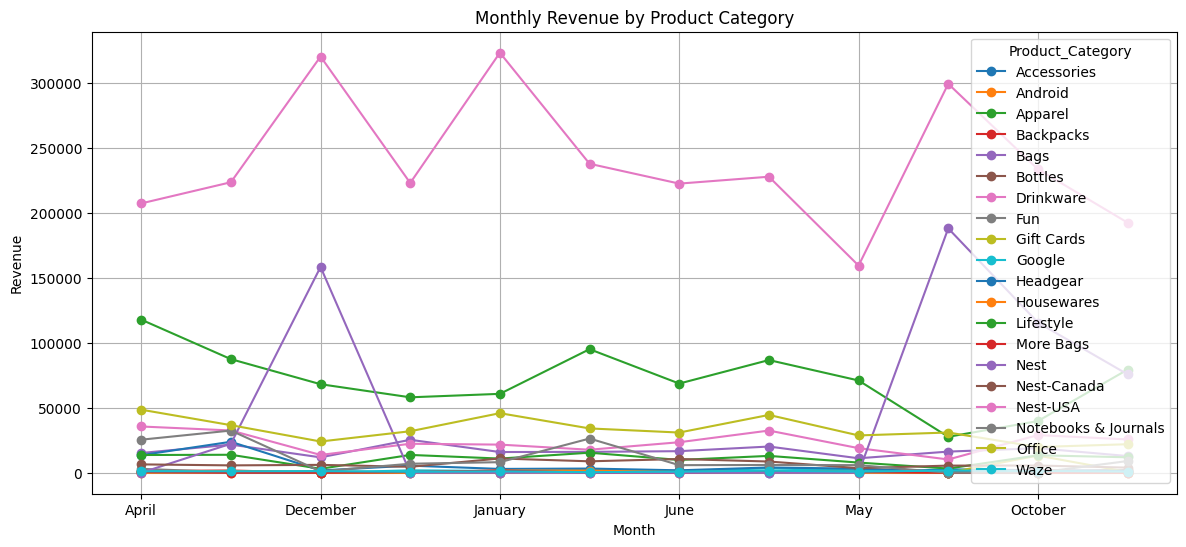

In [100]:
# Visualize Category Seasonality
import matplotlib.pyplot as plt

category_pivot.plot(
    figsize=(14,6),
    marker='o'
)
plt.title(
    'Monthly Revenue by Product Category'
)
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.grid(True)
plt.show()

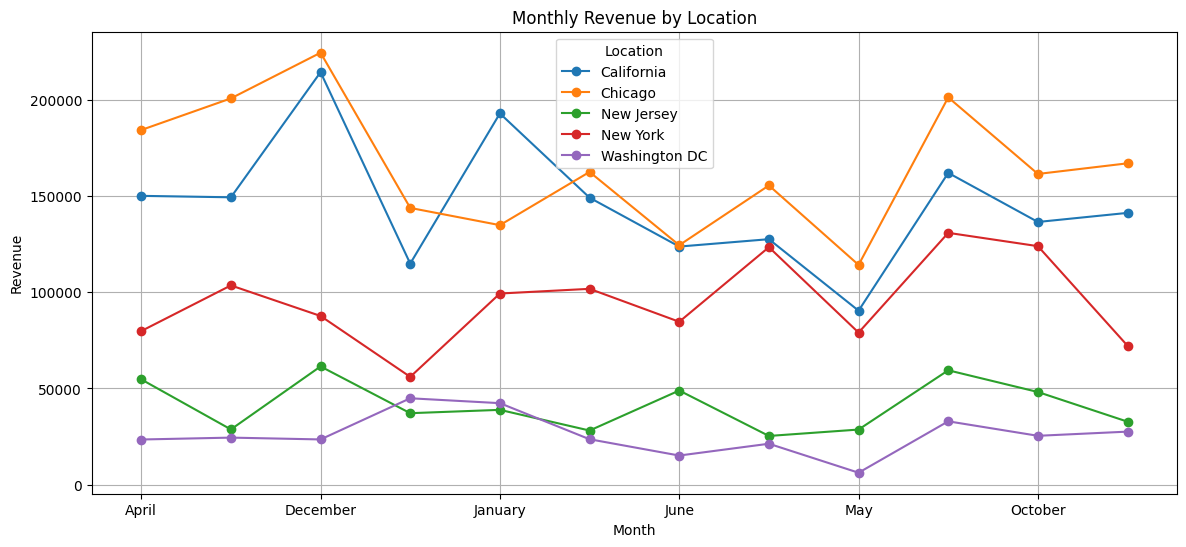

In [101]:
# Visualize Location Seasonality
location_pivot.plot(
    figsize=(14,6),
    marker='o'
)
plt.title(
    'Monthly Revenue by Location'
)
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.grid(True)
plt.show()

In [102]:
# Q9 - Analysis - Seasonal sales trends were analyzed by examining monthly revenue across product categories and customer locations.
# Peak and off-peak periods were identified to understand variations in customer demand. The analysis highlighted which categories
# and locations contribute most significantly during different times of the year. These insights can support inventory planning,
# marketing budget allocation, and promotional strategy development. During peak seasons, the company should ensure adequate
# inventory and logistics capacity, while off-peak periods can be supported through targeted promotions, personalized marketing
# campaigns, and location-specific initiatives to maintain revenue growth throughout the year.

In [104]:
# Q10 - Analyze daily sales trends to identify high-performing and low-performing days.

merged_df['Transaction_Date'] = pd.to_datetime(
    merged_df['Transaction_Date']
)

merged_df['Day_Name'] = (
    merged_df['Transaction_Date']
    .dt.day_name()
)

merged_df['Day_Number'] = (
    merged_df['Transaction_Date']
    .dt.dayofweek
)
# Calculate Daily Sales Metrics
daily_sales = (
    merged_df
    .groupby(
        ['Day_Number', 'Day_Name']
    )
    .agg(
        Revenue=('Invoice_Value', 'sum'),
        Orders=('Transaction_ID', 'nunique'),
        Quantity_Sold=('Quantity', 'sum'),
        Avg_Order_Value=('Invoice_Value', 'mean')
    )
    .reset_index()
    .sort_values('Day_Number')
)
daily_sales.round(2)

,Day_Number,Day_Name,Revenue,Orders,Quantity_Sold,Avg_Order_Value
0,0,Monday,434269.83,2130,11983,97.28
1,1,Tuesday,474374.02,2315,11317,102.88
2,2,Wednesday,1005051.31,4378,39797,113.09
3,3,Thursday,1016384.15,4278,44482,112.93
4,4,Friday,1053074.98,4233,52433,113.65
5,5,Saturday,832391.00,3872,37965,101.80
6,6,Sunday,858200.52,3855,40056,100.74


In [105]:
# Identify Highest and Lowest Performing Days
highest_day = daily_sales.loc[
    daily_sales['Revenue'].idxmax()
]
print("Highest Performing Day")
print(highest_day)

lowest_day = daily_sales.loc[
    daily_sales['Revenue'].idxmin()
]
print("Lowest Performing Day")
print(lowest_day)

Highest Performing Day
Day_Number                     4
Day_Name                  Friday
Revenue            1053074.97756
Orders                      4233
Quantity_Sold              52433
Avg_Order_Value       113.649361
Name: 4, dtype: object
Lowest Performing Day
Day_Number                    0
Day_Name                 Monday
Revenue            434269.82992
Orders                     2130
Quantity_Sold             11983
Avg_Order_Value       97.282668
Name: 0, dtype: object


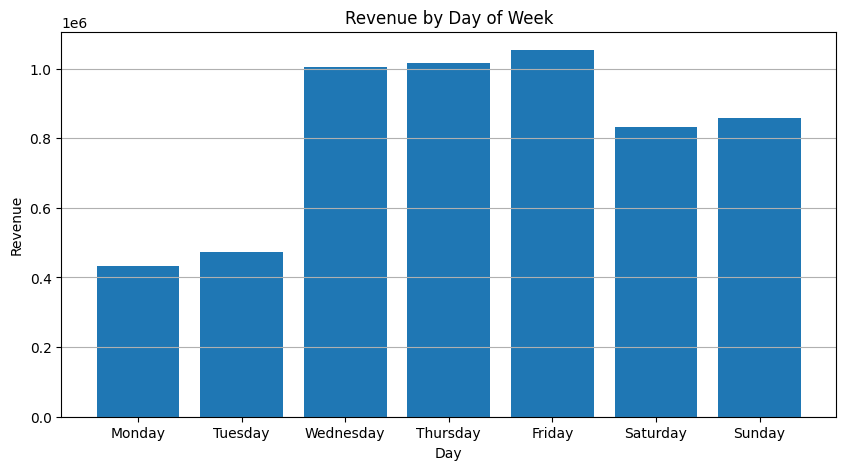

In [106]:
# Visualize Revenue by Day

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(
    daily_sales['Day_Name'],
    daily_sales['Revenue']
)
plt.title('Revenue by Day of Week')
plt.xlabel('Day')
plt.ylabel('Revenue')
plt.grid(axis='y')
plt.show()

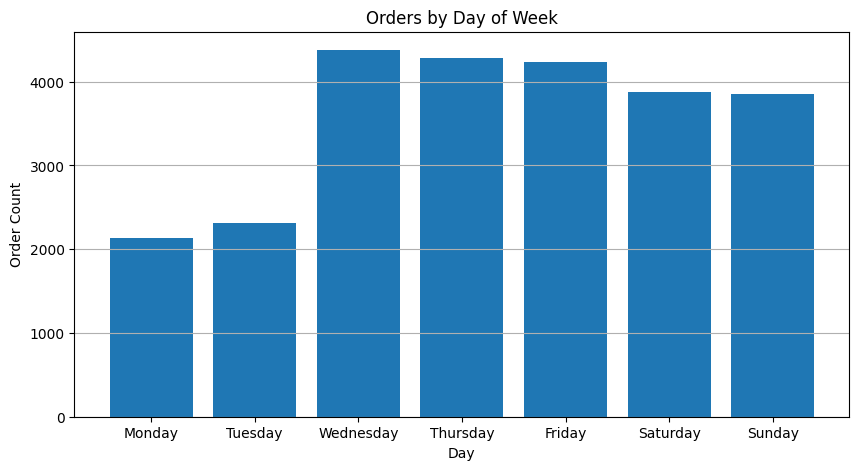

In [107]:
# Visualize Orders by Day

plt.figure(figsize=(10,5))
plt.bar(
    daily_sales['Day_Name'],
    daily_sales['Orders']
)
plt.title('Orders by Day of Week')
plt.xlabel('Day')
plt.ylabel('Order Count')
plt.grid(axis='y')
plt.show()

In [108]:
# Categorize High and Low Performing Days
avg_revenue = daily_sales['Revenue'].mean()

daily_sales['Performance'] = daily_sales['Revenue'].apply(
    lambda x: 'High' if x >= avg_revenue else 'Low'
)

daily_sales

,Day_Number,Day_Name,Revenue,Orders,Quantity_Sold,Avg_Order_Value,Performance
0,0,Monday,4.342698e+05,2130,11983,97.282668,Low
1,1,Tuesday,4.743740e+05,2315,11317,102.878773,Low
2,2,Wednesday,1.005051e+06,4378,39797,113.092305,High
3,3,Thursday,1.016384e+06,4278,44482,112.931572,High
4,4,Friday,1.053075e+06,4233,52433,113.649361,High
5,5,Saturday,8.323910e+05,3872,37965,101.796625,High
6,6,Sunday,8.582005e+05,3855,40056,100.739585,High


In [109]:
# Q10 - Analysis - Daily sales trends were analyzed by aggregating revenue, order count, quantity sold, and average order value by
# day of the week. High-performing and low-performing days were identified based on total revenue generated. The analysis revealed
# customer purchasing patterns across weekdays and weekends. To improve sales on slower days, the company can implement targeted
# promotions, free-shipping offers, loyalty rewards, personalized marketing campaigns, and bundle deals. These initiatives can
# help distribute demand more evenly across the week and maximize overall revenue.